# Simulação

A simulação será realizada em Python utilizando NumPy, Pandas e Matplotlib.

O objetivo é implementar o exemplo anterior por meio da convolução discreta e comparar a entrada, a resposta ao impulso e a saída do sistema.

## Metodologia

A simulação seguirá as seguintes etapas:

1. definir o vetor de índices discretos;
2. definir a sequência de entrada \(x[n]\);
3. definir a resposta ao impulso \(h[n]\);
4. calcular a saída utilizando a convolução discreta;
5. organizar os valores em uma tabela;
6. representar graficamente os sinais;
7. comparar o resultado computacional com o resultado obtido analiticamente.

## Implementação

Apresentar o código-fonte utilizado na simulação.

**Código da simulação:**

In [1]:
# ============================================================
# IMPORTAÇÕES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# CONFIGURAÇÃO DO TEMA GRÁFICO
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="paper"
)

 n  x[n]  h[n]  y[n]
 0     1     1     1
 1     2     1     3
 2     1     0     3
 3     0     0     1


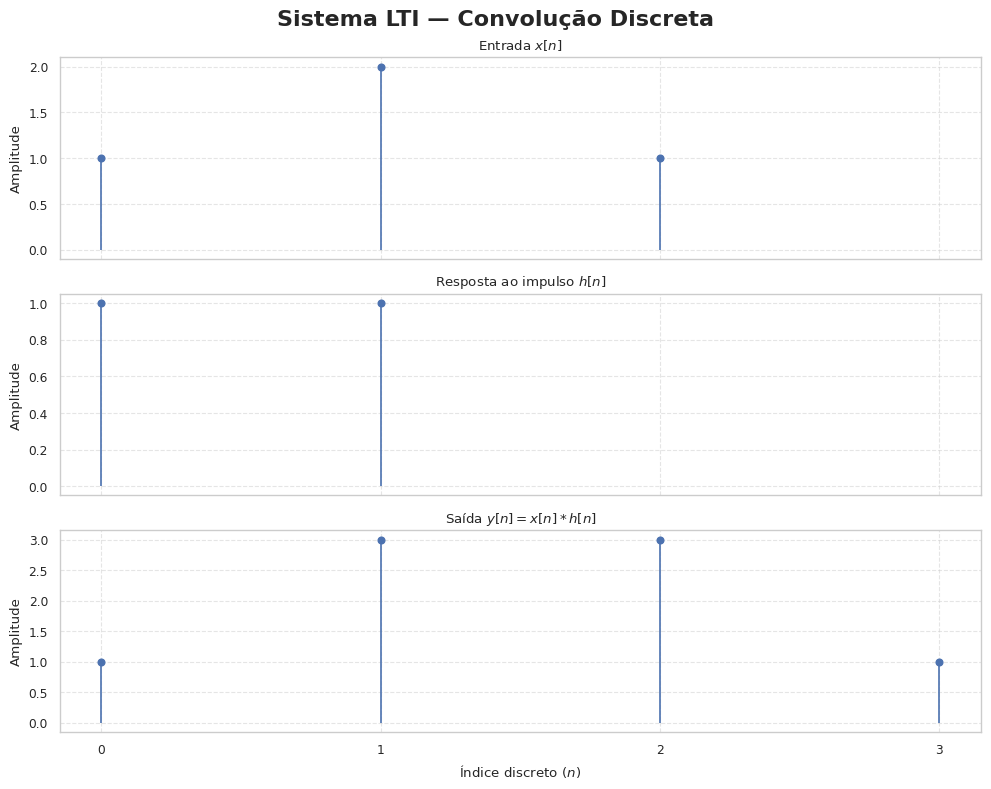

In [2]:
# ============================================================
# DEFINIÇÃO DOS SINAIS
# ============================================================

# Entrada:
# x[n] = δ[n] + 2δ[n-1] + δ[n-2]
x = np.array([1, 2, 1])

# Resposta ao impulso:
# h[n] = δ[n] + δ[n-1]
h = np.array([1, 1])


# ============================================================
# CÁLCULO DA CONVOLUÇÃO
# ============================================================

y = np.convolve(x, h)


# ============================================================
# DEFINIÇÃO DOS ÍNDICES
# ============================================================

n_x = np.arange(len(x))
n_h = np.arange(len(h))
n_y = np.arange(len(y))


# ============================================================
# CONSTRUÇÃO DA TABELA DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame({
    "n": n_y,
    "x[n]": np.pad(
        x,
        (0, len(y) - len(x))
    ),
    "h[n]": np.pad(
        h,
        (0, len(y) - len(h))
    ),
    "y[n]": y
})


# ============================================================
# EXIBIÇÃO DOS RESULTADOS
# ============================================================

print(df_resultados.to_string(index=False))


# ============================================================
# CONFIGURAÇÃO DA FIGURA
# ============================================================

fig, axs = plt.subplots(
    3,
    1,
    figsize=(10, 8),
    sharex=True
)

fig.suptitle(
    "Sistema LTI — Convolução Discreta",
    fontsize=16,
    fontweight="bold"
)


# ============================================================
# GRÁFICO DA ENTRADA
# ============================================================

axs[0].stem(
    n_x,
    x,
    basefmt=" "
)

axs[0].set_title(
    r"Entrada $x[n]$"
)

axs[0].set_ylabel(
    "Amplitude"
)

axs[0].set_xticks(n_y)
axs[0].grid(
    True,
    linestyle="--",
    alpha=0.5
)


# ============================================================
# GRÁFICO DA RESPOSTA AO IMPULSO
# ============================================================

axs[1].stem(
    n_h,
    h,
    basefmt=" "
)

axs[1].set_title(
    r"Resposta ao impulso $h[n]$"
)

axs[1].set_ylabel(
    "Amplitude"
)

axs[1].set_xticks(n_y)
axs[1].grid(
    True,
    linestyle="--",
    alpha=0.5
)


# ============================================================
# GRÁFICO DA SAÍDA
# ============================================================

axs[2].stem(
    n_y,
    y,
    basefmt=" "
)

axs[2].set_title(
    r"Saída $y[n] = x[n] * h[n]$"
)

axs[2].set_xlabel(
    "Índice discreto ($n$)"
)

axs[2].set_ylabel(
    "Amplitude"
)

axs[2].set_xticks(n_y)
axs[2].grid(
    True,
    linestyle="--",
    alpha=0.5
)


# ============================================================
# AJUSTES FINAIS
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    top=0.92
)

plt.show()